In [1]:
from google.colab import drive
drive.mount('/content/drive')  # follow the prompt


Mounted at /content/drive


In [2]:
ZIP_PATH = "/content/drive/MyDrive/Celeb-DF-v2_images.zip"   # <-- change me
EXTRACT_TO = "/content"                   # where to extract

# Create the folder (if it doesn't exist)
import os
os.makedirs(EXTRACT_TO, exist_ok=True)

# -q quiet, -o overwrite existing, -d destination
!unzip -q -o "$ZIP_PATH" -d "$EXTRACT_TO"


In [3]:
# Check GPU
!nvidia-smi

# Install libs
!pip -q install timm==1.0.9 torchmetrics==1.4.0rc0 pytorch-grad-cam==1.5.2


Mon Aug 11 06:34:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os, glob

root = "/content/Celeb-DF-v2_images"
real_dir = os.path.join(root, "Celeb-real_images")
fake_dir = os.path.join(root, "Celeb-synthesis_images")

n_real = len(glob.glob(real_dir + "/**/*.*", recursive=True))
n_fake = len(glob.glob(fake_dir + "/**/*.*", recursive=True))

print("Real images:", n_real)
print("Fake images:", n_fake)


Real images: 10351
Fake images: 97753


In [8]:
import torch, os, random, numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Correct root & folder names (case-sensitive)
DATA_DIR = "/content/Celeb-DF-v2_images"  # root
REAL_DIR = os.path.join(DATA_DIR, "Celeb-real_images")
FAKE_DIR = os.path.join(DATA_DIR, "Celeb-synthesis_images")

IMG_SIZE = 299           # Xception likes 299
BATCH_SIZE = 32
EPOCHS = 5               # changed from 15 → 5 for faster runs
VAL_SPLIT = 0.15
LR = 3e-4
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Quick sanity check
import glob
n_real = len(glob.glob(REAL_DIR + "/**/*.*", recursive=True))
n_fake = len(glob.glob(FAKE_DIR + "/**/*.*", recursive=True))
print("Device:", DEVICE)
print("Real images:", n_real)
print("Fake images:", n_fake)


Device: cuda
Real images: 10351
Fake images: 97753


In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Normalization for ImageNet pretrained models
mean = (0.485, 0.456, 0.406)
std  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Load dataset from root directory
full_ds = datasets.ImageFolder(DATA_DIR, transform=train_tfms)
print("Class mapping:", full_ds.class_to_idx)

# Split into train/val
val_len = int(len(full_ds) * VAL_SPLIT)
train_len = len(full_ds) - val_len
train_ds, val_ds = random_split(full_ds, [train_len, val_len])

# Apply val transforms
val_ds.dataset.transform = val_tfms

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Class mapping: {'Celeb-real_images': 0, 'Celeb-synthesis_images': 1}


In [10]:
import timm
import torch.nn as nn

# Create Xception model
model = timm.create_model("xception", pretrained=True, num_classes=1)  # 1 logit for binary classification
model = model.to(DEVICE)

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
/tmp/ipython-input-2865123454.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


In [11]:
!pip install torchmetrics --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.5 MB/s eta 0:00:00


In [11]:
import math, time, os
from torchmetrics.classification import BinaryAccuracy, BinaryAUROC

def evaluate(loader):
    model.eval()
    acc = BinaryAccuracy(threshold=0.5).to(DEVICE)
    auroc = BinaryAUROC().to(DEVICE)
    running_loss, n = 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True).float().view(-1, 1)

            logits = model(x)
            loss = criterion(logits, y)
            running_loss += loss.item() * x.size(0)

            probs = torch.sigmoid(logits)
            acc.update(probs, y.int())
            auroc.update(probs, y.int())
            n += x.size(0)

    return running_loss / max(1, n), acc.compute().item(), auroc.compute().item()

best_val_loss = math.inf
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    running_loss, n = 0.0, 0

    for x, y in train_loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True).float().view(-1, 1)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x.size(0)
        n += x.size(0)

    train_loss = running_loss / max(1, n)
    val_loss, val_acc, val_auroc = evaluate(val_loader)

    print(f"Epoch {epoch:02d}/{EPOCHS} | {time.time()-t0:.1f}s "
          f"TrainLoss {train_loss:.4f}  ValLoss {val_loss:.4f} "
          f"ValAcc {val_acc:.4f}  ValAUROC {val_auroc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_auroc": val_auroc,
            "class_to_idx": full_ds.class_to_idx,
            "img_size": IMG_SIZE,
        }, "checkpoints/xception_celebdf_best.pt")
        print("✅ Saved best checkpoint.")


/tmp/ipython-input-3844203554.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):


Epoch 01/5 | 1071.0s TrainLoss 0.0520  ValLoss 0.0221 ValAcc 0.9922  ValAUROC 0.9992
✅ Saved best checkpoint.
Epoch 02/5 | 1069.7s TrainLoss 0.0175  ValLoss 0.0187 ValAcc 0.9932  ValAUROC 0.9993
✅ Saved best checkpoint.
Epoch 03/5 | 1065.1s TrainLoss 0.0125  ValLoss 0.0241 ValAcc 0.9924  ValAUROC 0.9995
Epoch 04/5 | 1063.0s TrainLoss 0.0090  ValLoss 0.0146 ValAcc 0.9949  ValAUROC 0.9998
✅ Saved best checkpoint.
Epoch 05/5 | 1059.8s TrainLoss 0.0076  ValLoss 0.0117 ValAcc 0.9954  ValAUROC 0.9998
✅ Saved best checkpoint.


In [12]:
from PIL import Image
import torch
import timm

def load_checkpoint(path="checkpoints/xception_celebdf_best.pt"):
    """Load a trained model from checkpoint."""
    ckpt = torch.load(path, map_location=DEVICE)
    model = timm.create_model("xception", pretrained=False, num_classes=1).to(DEVICE)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    return model, ckpt

infer_tfms = val_tfms  # use same transforms as validation

@torch.no_grad()
def predict_image(img_path, threshold=0.5):
    """Predict whether an image is real or fake."""
    img = Image.open(img_path).convert("RGB")
    x = infer_tfms(img).unsqueeze(0).to(DEVICE)
    logits = model(x)
    prob_fake = torch.sigmoid(logits).item()
    pred = 1 if prob_fake >= threshold else 0
    classes = {v: k for k, v in full_ds.class_to_idx.items()}
    return prob_fake, classes[pred]

# Load your trained model
model, ckpt = load_checkpoint("checkpoints/xception_celebdf_best.pt")

# Example usage:
# img_path = "/content/Celeb-DF-v2_images/Celeb-synthesis_images/sample.jpg"
# prob_fake, label = predict_image(img_path)
# print(f"Prediction: {label} | Fake probability: {prob_fake:.4f}")


In [14]:
!pip install grad-cam --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [16]:
# Downgrade to Python 3.10
!sudo apt-get install python3.10 python3.10-distutils python3.10-dev
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 2
!curl -sS https://bootstrap.pypa.io/get-pip.py | python3.10

# Restart runtime after this, then:
!pip install pytorch-grad-cam --quiet


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'python3-distutils' instead of 'python3.10-distutils'
python3-distutils is already the newest version (3.10.8-1~22.04).
python3.10 is already the newest version (3.10.12-1~22.04.10).
python3.10 set to manually installed.
python3.10-dev is already the newest version (3.10.12-1~22.04.10).
python3.10-dev set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.5 MB/s  0:00:00
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
Using cached wheel-0.45.1-py3-none-any.whl (72 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pip]
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distr

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
from PIL import Image

target_layers = [model.conv3] if hasattr(model, "conv3") else [list(model.children())[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def gradcam_on_image(img_path, save_path=None):
    img_pil = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    x = infer_tfms(img_pil).unsqueeze(0).to(DEVICE)

    grayscale_cam = cam(input_tensor=x)[0]  # Grad-CAM mask
    vis = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    if save_path:
        Image.fromarray(vis).save(save_path)
        print(f"Grad-CAM saved to {save_path}")
    return Image.fromarray(vis)

# Example usage
# heatmap_img = gradcam_on_image("/content/Celeb-DF-v2_images/Celeb-synthesis_images/sample.jpg")
# display(heatmap_img)


In [19]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
from PIL import Image

# Pick a target layer for Xception
target_layers = [model.conv3] if hasattr(model, "conv3") else [list(model.children())[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def predict_with_gradcam(img_path, threshold=0.5, save_path=None):
    """Predict label + probability and generate Grad-CAM heatmap."""
    # 1️⃣ Load & preprocess
    img_pil = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    x = infer_tfms(img_pil).unsqueeze(0).to(DEVICE)

    # 2️⃣ Prediction
    model.eval()
    with torch.no_grad():
        logits = model(x)
        prob_fake = torch.sigmoid(logits).item()
    pred = 1 if prob_fake >= threshold else 0
    classes = {v: k for k, v in full_ds.class_to_idx.items()}
    label = classes[pred]

    # 3️⃣ Grad-CAM
    grayscale_cam = cam(input_tensor=x)[0]
    vis = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    heatmap_img = Image.fromarray(vis)

    # 4️⃣ Save if needed
    if save_path:
        heatmap_img.save(save_path)
        print(f"Grad-CAM saved to {save_path}")

    return label, prob_fake, heatmap_img

# Example usage:
# label, prob, heatmap = predict_with_gradcam(
#     "/content/Celeb-DF-v2_images/Celeb-synthesis_images/sample.jpg"
# )
# print(f"Prediction: {label} | Fake Probability: {prob:.4f}")
# display(heatmap)


In [20]:
import matplotlib.pyplot as plt

def show_prediction_with_gradcam(img_path, threshold=0.5):
    """Display original image and Grad-CAM heatmap side by side."""
    label, prob_fake, heatmap_img = predict_with_gradcam(img_path, threshold=threshold)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Original image
    original_img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    axes[0].imshow(original_img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Grad-CAM image
    axes[1].imshow(heatmap_img)
    axes[1].set_title(f"Grad-CAM\nPred: {label}\nFake Prob: {prob_fake:.4f}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Example usage:
# show_prediction_with_gradcam("/content/Celeb-DF-v2_images/Celeb-synthesis_images/sample.jpg")


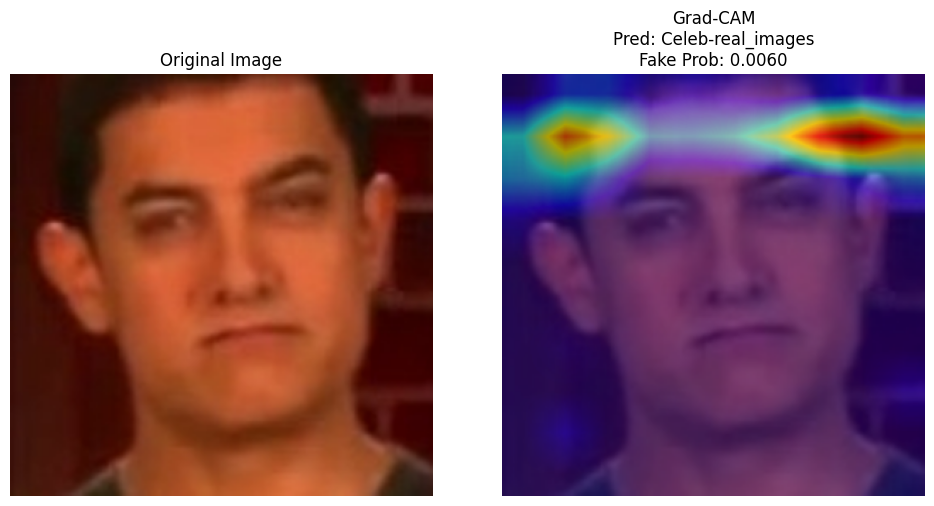

In [25]:
# ==== Load model checkpoint ====
model, ckpt = load_checkpoint("checkpoints/xception_celebdf_best.pt")

# ==== Pick an image to test ====
test_image_path = "/content/Celeb-DF-v2_images/Celeb-real_images/id0_0000_2.jpg"

# ==== Predict and show Grad-CAM ====
show_prediction_with_gradcam(test_image_path, threshold=0.5)


In [37]:
# 1. Install Python 3.10
!sudo apt-get install python3.10 python3.10-distutils python3.10-dev -y
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 2
!curl -sS https://bootstrap.pypa.io/get-pip.py | python3.10


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'python3-distutils' instead of 'python3.10-distutils'
python3-distutils is already the newest version (3.10.8-1~22.04).
python3.10 is already the newest version (3.10.12-1~22.04.10).
python3.10-dev is already the newest version (3.10.12-1~22.04.10).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.2
    Uninstalling pip-25.2:
      Successfully uninstalled pip-25.2


In [43]:
import sys
!{sys.executable} -m pip install lime scikit-image --quiet


  Preparing metadata (setup.py) ... done


In [44]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

def predict_for_lime(images):
    """Convert batch of numpy images to model predictions for LIME."""
    # Convert to tensor and normalize
    batch = torch.stack([infer_tfms(Image.fromarray(img)) for img in images], dim=0)
    batch = batch.to(DEVICE)
    with torch.no_grad():
        logits = model(batch)
        probs = torch.sigmoid(logits).cpu().numpy()
    # Return probability for "fake" class
    return np.hstack([1 - probs, probs])  # shape: (n_samples, 2)


  0%|          | 0/1000 [00:00<?, ?it/s]

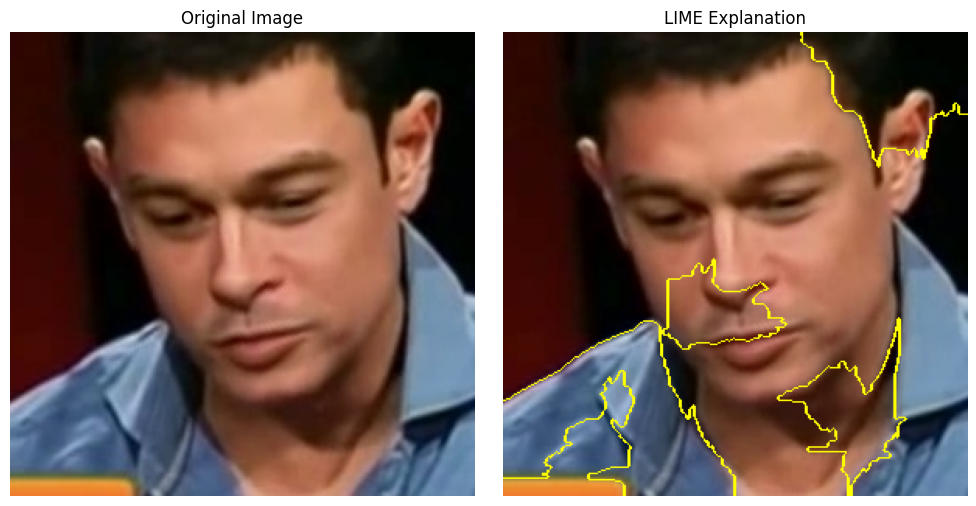

In [46]:
# Pick a fake (synthesis) image
fake_image_path = "/content/id0_id1_0005_16.jpg"
img_pil = Image.open(fake_image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
img_np = np.array(img_pil)

# Run LIME
explanation = explainer.explain_instance(
    img_np,
    classifier_fn=predict_for_lime,
    top_labels=1,
    hide_color=0,
    num_samples=1000  # higher = more accurate, slower
)

# Get mask for top predicted class
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

# Show original + LIME mask
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_np)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(mark_boundaries(temp / 255.0, mask))
ax[1].set_title("LIME Explanation")
ax[1].axis("off")

plt.tight_layout()
plt.show()


In [47]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
from PIL import Image

# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

def predict_for_lime(images):
    """Batch of numpy images → model predictions."""
    batch = torch.stack([
        infer_tfms(Image.fromarray(img))
        for img in images
    ], dim=0).to(DEVICE)

    with torch.no_grad():
        logits = model(batch)
        probs = torch.sigmoid(logits).cpu().numpy()

    # Return prob for both classes: real (0) and fake (1)
    return np.hstack([1 - probs, probs])

# Pick a fake image
img_path = "/content/id0_id1_0005_16.jpg"
img_pil = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
img_np = np.array(img_pil)

# Explain with LIME
explanation = explainer.explain_instance(
    img_np,
    classifier_fn=predict_for_lime,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

# Get weights for the predicted class
top_label = explanation.top_labels[0]
weights = explanation.local_exp[top_label]  # list of (superpixel_id, weight)

# Sort by absolute weight
weights_sorted = sorted(weights, key=lambda x: abs(x[1]), reverse=True)

# Text explanation: show top 5 most influential regions
print(f"Text explanation for {img_path}:")
for sp_id, weight in weights_sorted[:5]:
    influence = "FAKE" if weight > 0 else "REAL"
    print(f" - Superpixel {sp_id} contributed {abs(weight):.4f} towards {influence}")


  0%|          | 0/1000 [00:00<?, ?it/s]

Text explanation for /content/id0_id1_0005_16.jpg:
 - Superpixel 23 contributed 0.0142 towards FAKE
 - Superpixel 11 contributed 0.0130 towards FAKE
 - Superpixel 39 contributed 0.0130 towards FAKE
 - Superpixel 25 contributed 0.0129 towards FAKE
 - Superpixel 36 contributed 0.0119 towards FAKE


In [58]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def explain_image(img_path, threshold=0.5):
    # Load and preprocess
    img_pil = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    x = infer_tfms(img_pil).unsqueeze(0).to(DEVICE)

    # Prediction
    model.eval()
    with torch.no_grad():
        logits = model(x)
        prob_fake = torch.sigmoid(logits).item()
    label = "FAKE" if prob_fake >= threshold else "REAL"

    # Grad-CAM
    target_layers = [model.conv3] if hasattr(model, "conv3") else [list(model.children())[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=x)[0]
    gradcam_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # LIME
    explainer = lime_image.LimeImageExplainer()
    def predict_for_lime(images):
        batch = torch.stack([infer_tfms(Image.fromarray(img)) for img in images], dim=0).to(DEVICE)
        with torch.no_grad():
            logits = model(batch)
            probs = torch.sigmoid(logits).cpu().numpy()
        return np.hstack([1 - probs, probs])

    explanation = explainer.explain_instance(
        (img_np*255).astype(np.uint8),
        classifier_fn=predict_for_lime,
        top_labels=1,
        hide_color=0,
        num_samples=500
    )

    weights = explanation.local_exp[explanation.top_labels[0]]
    top_region, top_weight = sorted(weights, key=lambda x: abs(x[1]), reverse=True)[0]
    lime_text = "Suspicious regions detected — possibly manipulated areas or artifacts."

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_pil)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(gradcam_img)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")

    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True,
                                                num_features=10, hide_rest=False)
    axes[2].imshow(mark_boundaries(temp / 255.0, mask))
    axes[2].set_title("LIME Regions")
    axes[2].axis("off")

    plt.suptitle(f"Prediction: {label} (Confidence: {prob_fake*100:.2f}%)\n\n"
                 f"LIME Text Explanation: {lime_text}", fontsize=12)
    plt.tight_layout()
    plt.show()


  0%|          | 0/500 [00:00<?, ?it/s]

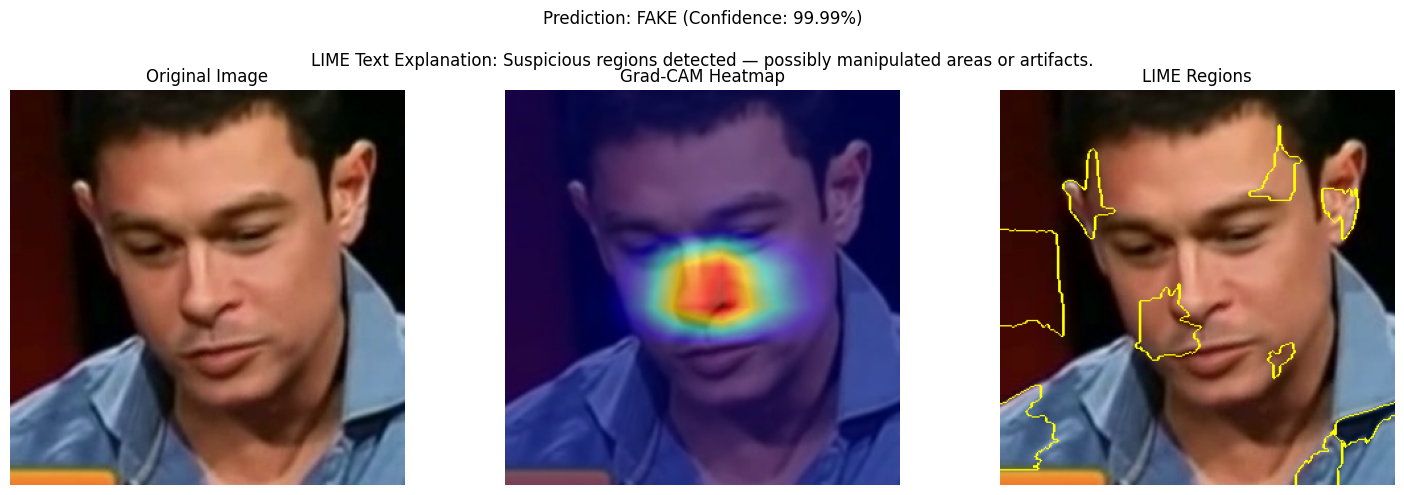

In [59]:
explain_image("/content/id0_id1_0005_16.jpg")
